# 📱 Google Play Store Analysis

## Objective

The objective of this project is to analyze the Google Play Store ecosystem by cleaning messy real-world data, exploring app categories, analyzing ratings, pricing trends, installs, and performing sentiment analysis on user reviews.

This project was completed as part of the **Oasis Infobyte Data Analytics Internship – Level 2 Task 4**.

In [10]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

# Create images folder only if it doesn't already exist
if not os.path.exists("images"):
    os.mkdir("images")

print("Libraries imported successfully!")

Libraries imported successfully!


In [11]:
apps = pd.read_csv("googleplaystore.csv")
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

In [12]:
print("Apps Dataset Shape:", apps.shape)
print("Reviews Dataset Shape:", reviews.shape)

Apps Dataset Shape: (10841, 13)
Reviews Dataset Shape: (64295, 5)


In [13]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [15]:
apps.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.2 MB


In [16]:
print("Apps Missing Values")
print(apps.isnull().sum())

print("\nReviews Missing Values")
print(reviews.isnull().sum())

Apps Missing Values
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Reviews Missing Values
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [17]:
print("Duplicate Apps:", apps.duplicated().sum())

print("Duplicate Reviews:", reviews.duplicated().sum())

Duplicate Apps: 483
Duplicate Reviews: 33616


In [18]:
print(apps.columns)

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')


# Data Cleaning

The dataset contains several columns stored as strings (Installs, Size, Price, Reviews). These are converted into appropriate numeric formats. Missing values and duplicate records are also handled.

In [19]:
apps.drop_duplicates(inplace=True)

reviews.drop_duplicates(inplace=True)

print("Apps Shape:", apps.shape)
print("Reviews Shape:", reviews.shape)

Apps Shape: (10358, 13)
Reviews Shape: (30679, 5)


In [20]:
apps.dropna(subset=["Rating"], inplace=True)

reviews.dropna(subset=["Translated_Review"], inplace=True)

print(apps.isnull().sum())

print(reviews.isnull().sum())

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    1
Genres            0
Last Updated      0
Current Ver       4
Android Ver       3
dtype: int64
App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64


In [21]:
apps["Reviews"] = pd.to_numeric(
    apps["Reviews"],
    errors="coerce"
)

In [22]:
apps["Installs"] = (
    apps["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps["Installs"] = pd.to_numeric(
    apps["Installs"],
    errors="coerce"
)

In [23]:
apps["Price"] = (
    apps["Price"]
    .str.replace("$", "", regex=False)
)

apps["Price"] = pd.to_numeric(
    apps["Price"],
    errors="coerce"
)

In [24]:
def clean_size(size):

    if pd.isna(size):
        return np.nan

    if size == "Varies with device":
        return np.nan

    if "M" in size:
        return float(size.replace("M", ""))

    if "k" in size:
        return float(size.replace("k", "")) / 1024

    return np.nan


apps["Size"] = apps["Size"].apply(clean_size)

In [25]:
apps["Last Updated"] = pd.to_datetime(
    apps["Last Updated"],
    errors="coerce"
)

In [26]:
apps.info()

<class 'pandas.DataFrame'>
Index: 8893 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             8893 non-null   str           
 1   Category        8893 non-null   str           
 2   Rating          8893 non-null   float64       
 3   Reviews         8892 non-null   float64       
 4   Size            7424 non-null   float64       
 5   Installs        8892 non-null   float64       
 6   Type            8893 non-null   str           
 7   Price           8892 non-null   float64       
 8   Content Rating  8892 non-null   str           
 9   Genres          8893 non-null   str           
 10  Last Updated    8892 non-null   datetime64[us]
 11  Current Ver     8889 non-null   str           
 12  Android Ver     8890 non-null   str           
dtypes: datetime64[us](1), float64(5), str(7)
memory usage: 1.6 MB


# Category Analysis

This analysis identifies which app categories are the most populated in the Google Play Store.

In [27]:
category_count = apps["Category"].value_counts()

category_count.head(10)

Category
FAMILY             1718
GAME               1074
TOOLS               734
PRODUCTIVITY        334
FINANCE             317
PERSONALIZATION     310
COMMUNICATION       307
LIFESTYLE           305
PHOTOGRAPHY         304
MEDICAL             302
Name: count, dtype: int64

In [45]:
import os

print(os.getcwd())

c:\Users\userp\Documents\Oasis_Infobyte_Internship\OIBSIP\DataAnalytics-L8-GooglePlayStoreAnalysis


In [47]:
import os

print("Current Folder:", os.getcwd())
print("Images Exists:", os.path.exists("images"))
print("Is Folder:", os.path.isdir("images"))

Current Folder: c:\Users\userp\Documents\Oasis_Infobyte_Internship\OIBSIP\DataAnalytics-L8-GooglePlayStoreAnalysis
Images Exists: True
Is Folder: False


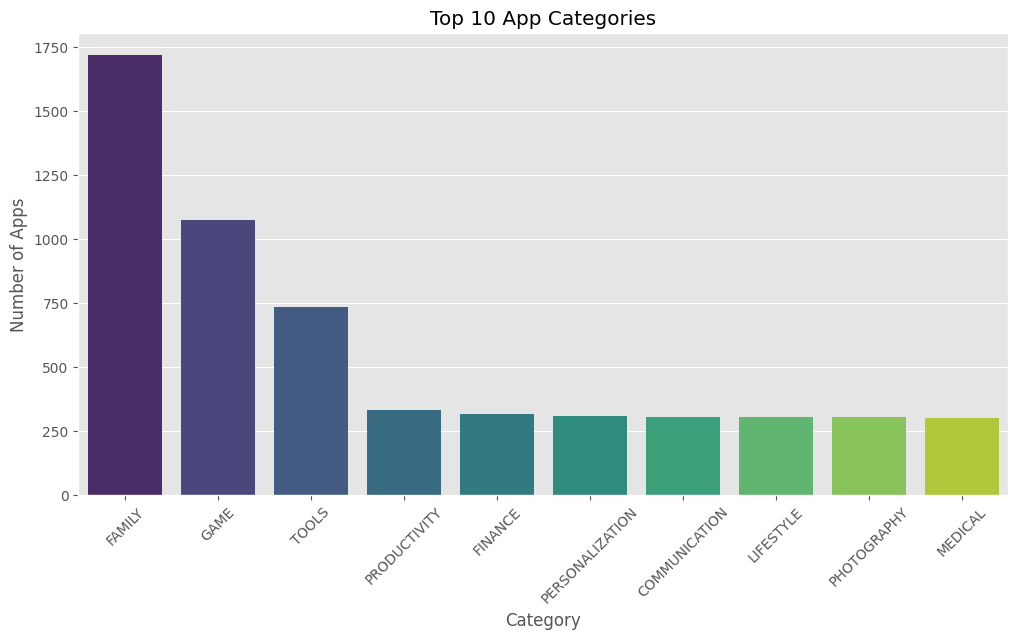

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=category_count.index[:10],
    y=category_count.values[:10],
    palette="viridis"
)

plt.xticks(rotation=45)

plt.title("Top 10 App Categories")

plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.savefig("images/top_10_app_categories.png", dpi=300,bbox_inches="tight")

plt.show()


# Ratings Analysis

Analyze the distribution of ratings and identify the average rating for each app category.

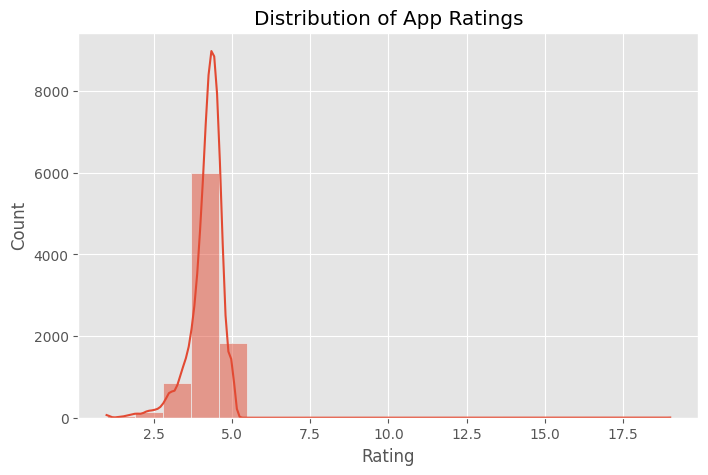

<Figure size 640x480 with 0 Axes>

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(
    apps["Rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")

plt.xlabel("Rating")

plt.show()
plt.savefig("images/Distribution of App Ratings.png", dpi=300,bbox_inches="tight")


In [30]:
avg_rating = (
    apps.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

avg_rating.head(10)

Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.375969
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.347458
PERSONALIZATION         4.333871
PARENTING               4.300000
GAME                    4.281285
BEAUTY                  4.278571
HEALTH_AND_FITNESS      4.261450
Name: Rating, dtype: float64

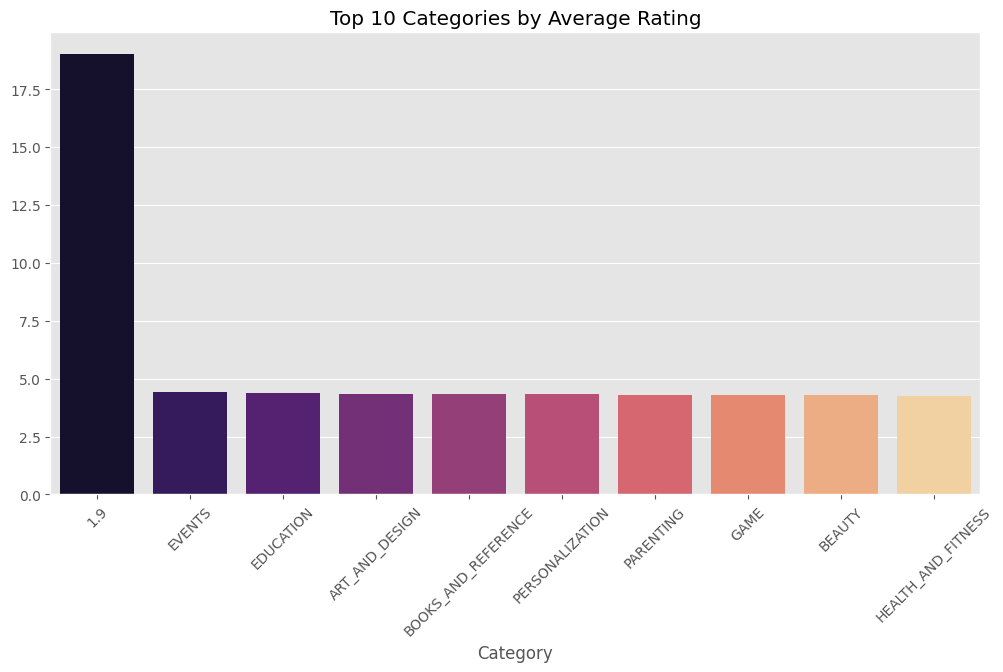

<Figure size 640x480 with 0 Axes>

In [54]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_rating.index[:10],
    y=avg_rating.values[:10],
    palette="magma"
)

plt.xticks(rotation=45)

plt.title("Top 10 Categories by Average Rating")

plt.show()

plt.savefig("images/top_10_categories_by_average_rating.png", dpi=300,bbox_inches="tight")

# Size vs Installs Analysis

This analysis explores the relationship between application size and the number of installs.

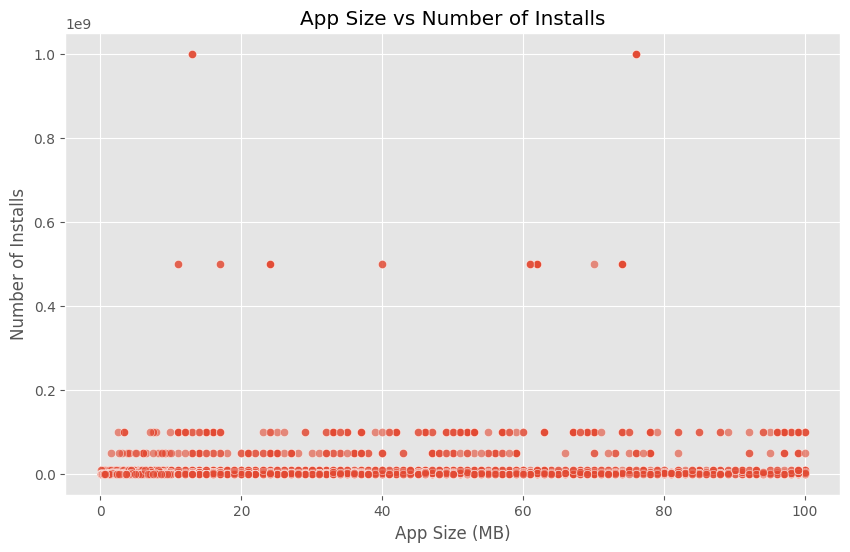

<Figure size 640x480 with 0 Axes>

In [55]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=apps,
    x="Size",
    y="Installs",
    alpha=0.6
)

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.show()
plt.savefig("images/app_size_vs_installs.png", dpi=300, bbox_inches="tight")

# Pricing Analysis

Analyze the distribution of Free and Paid applications and examine the pricing of paid apps.

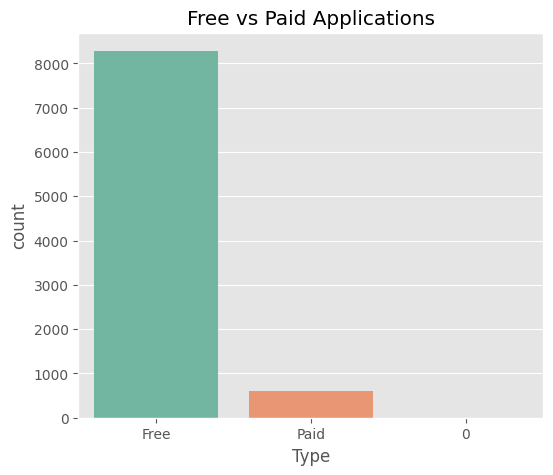

<Figure size 640x480 with 0 Axes>

In [56]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=apps,
    x="Type",
    palette="Set2"
)

plt.title("Free vs Paid Applications")

plt.show()
plt.savefig("images/free_vs_paid_apps.png", dpi=300, bbox_inches="tight")

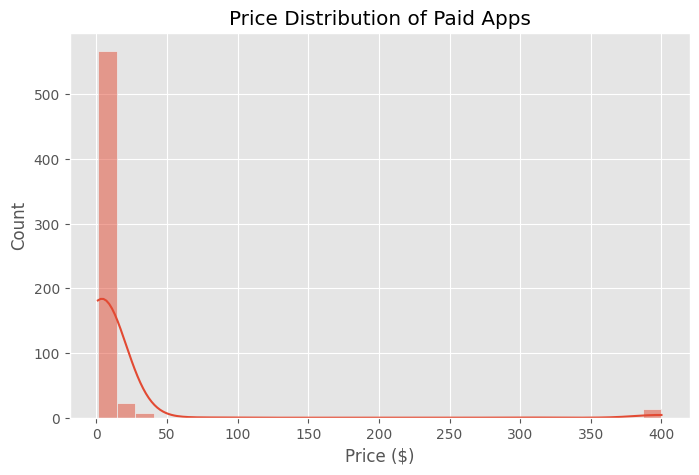

<Figure size 640x480 with 0 Axes>

In [57]:
paid_apps = apps[apps["Type"] == "Paid"]

plt.figure(figsize=(8,5))

sns.histplot(
    paid_apps["Price"],
    bins=30,
    kde=True
)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")

plt.show()
plt.savefig("images/price_distribution_paid_apps.png", dpi=300, bbox_inches="tight")

In [35]:
apps["Estimated_Revenue"] = apps["Installs"] * apps["Price"]

revenue = (
    apps.groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue.head(10)

Category
FAMILY             1.857743e+08
LIFESTYLE          5.758394e+07
GAME               4.098684e+07
FINANCE            2.572664e+07
PHOTOGRAPHY        8.941050e+06
MEDICAL            8.371355e+06
PERSONALIZATION    7.786310e+06
TOOLS              5.462910e+06
SPORTS             4.706154e+06
PRODUCTIVITY       4.304452e+06
Name: Estimated_Revenue, dtype: float64

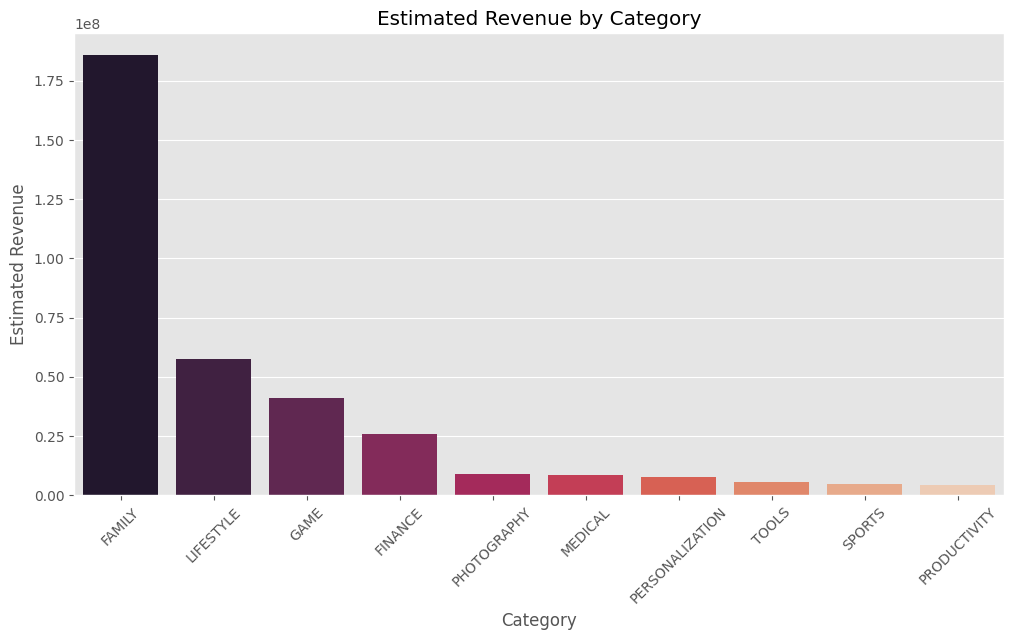

<Figure size 640x480 with 0 Axes>

In [58]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=revenue.index[:10],
    y=revenue.values[:10],
    palette="rocket"
)

plt.xticks(rotation=45)

plt.title("Estimated Revenue by Category")

plt.ylabel("Estimated Revenue")

plt.show()
plt.savefig("images/estimated_revenue_by_category.png", dpi=300, bbox_inches="tight")

# Sentiment Analysis using TextBlob

User reviews are classified into Positive, Neutral, and Negative categories using TextBlob polarity scores.

In [37]:
def sentiment(text):

    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

In [38]:
reviews["Sentiment"] = reviews["Translated_Review"].apply(sentiment)

reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000


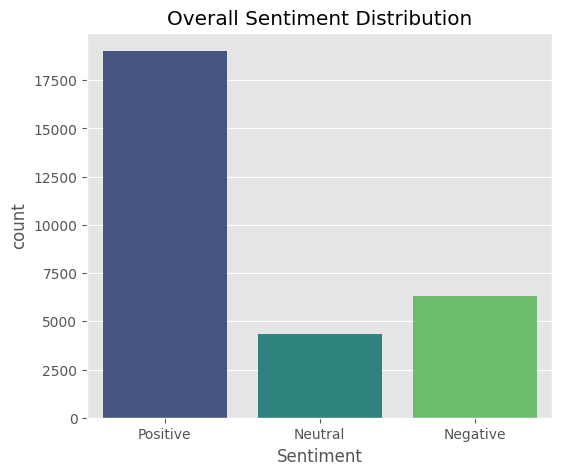

<Figure size 640x480 with 0 Axes>

In [59]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=reviews,
    x="Sentiment",
    palette="viridis"
)

plt.title("Overall Sentiment Distribution")

plt.show()
plt.savefig("images/overall_sentiment_distribution.png", dpi=300, bbox_inches="tight")

In [40]:
merged = pd.merge(
    apps,
    reviews,
    on="App",
    how="inner"
)

merged.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Estimated_Revenue,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.0,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.0,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.0,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.0,I love colors inspyering,Positive,0.500,0.600000
4,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.0,I hate,Negative,-0.800,0.900000


In [41]:
sentiment_category = pd.crosstab(
    merged["Category"],
    merged["Sentiment"]
)

sentiment_category.head()

Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,54,60,240
AUTO_AND_VEHICLES,17,36,230
BEAUTY,60,81,176
BOOKS_AND_REFERENCE,108,123,480
BUSINESS,144,201,458


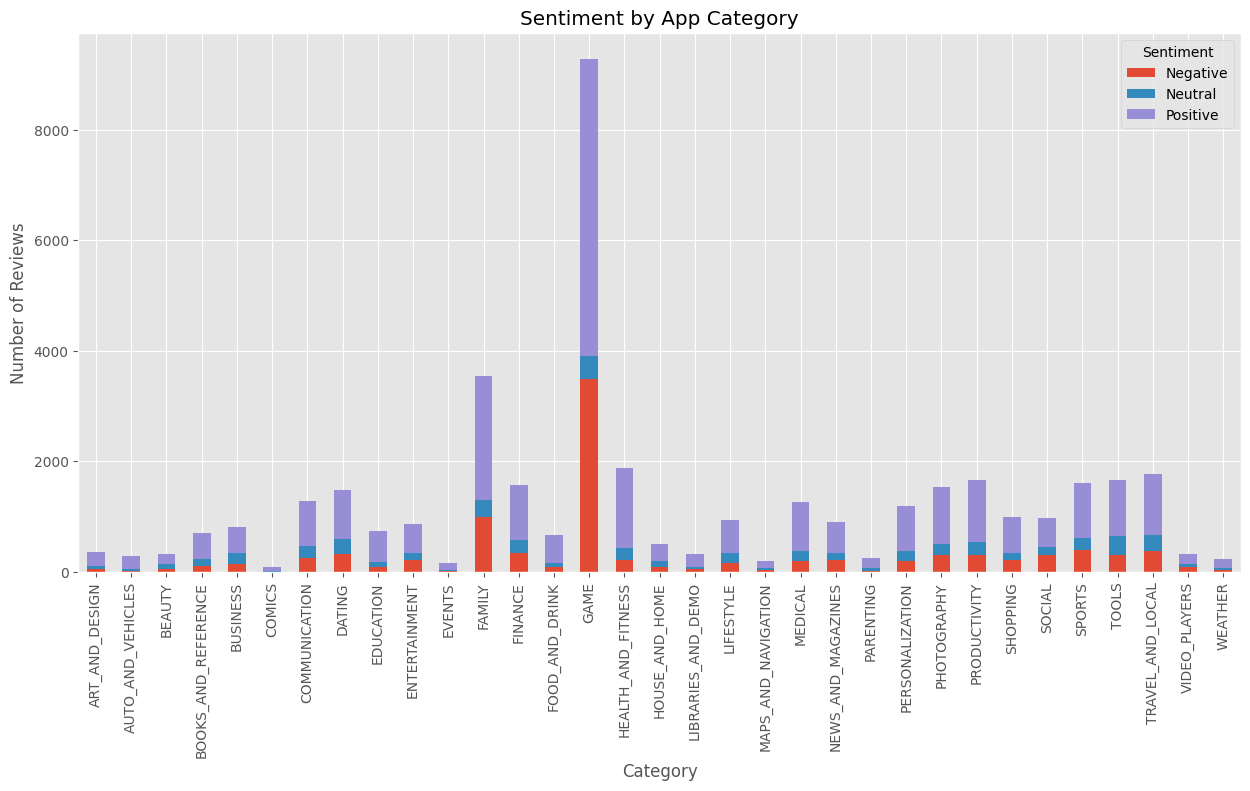

<Figure size 640x480 with 0 Axes>

In [60]:
sentiment_category.plot(
    kind="bar",
    stacked=True,
    figsize=(15,7)
)

plt.title("Sentiment by App Category")

plt.xlabel("Category")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=90)

plt.show()
plt.savefig("images/sentiment_by_app_category.png", dpi=300, bbox_inches="tight")

# Conclusion

## Insight 1

The **Family**, **Game**, and **Tools** categories contain the largest number of applications, indicating high competition within these markets.

## Insight 2

Most applications on the Google Play Store are **free**, while paid applications represent only a small percentage.

## Insight 3

Applications with higher ratings generally receive significantly more installs, and positive user sentiment is strongly associated with successful applications.

## Real-World Recommendation

A developer planning to launch a new application should:

- Target categories with growing demand but lower competition.
- Focus on maintaining ratings above 4.3.
- Prioritize positive user experience to increase positive reviews.
- Consider a free application with in-app purchases instead of a high upfront price.